# Event-Type Classifier — Shift & Incident Log

**Goal:** Given a free-text narrative written by staff, automatically classify
it into one of six event types used across the SUD-rehab campuses:
*Behavioral, Incident, Medical, Maintenance, Visitor, Other.*

**Why it matters:** Staff sometimes logs an incident under the wrong category,
and consistent classification drives meaningful analytics on the dashboard.
A classifier that suggests the type as the user types reduces friction and
improves data quality — a classic NLP win for a healthcare-adjacent tool.

**Skills demonstrated:**
- Text preprocessing (tokenisation, stopword removal, TF-IDF vectorisation)
- Supervised classification (Logistic Regression, LinearSVC)
- Evaluation: precision / recall / F1 per class, macro + weighted averages
- Class-imbalance handling (`class_weight='balanced'`, stratified split)
- Model comparison and confusion-matrix analysis
- Feature importance from learned coefficients
- Error analysis (what the model gets wrong and why)

> **Data note:** The dataset is synthetic but realistic — 900 entries generated
> with domain vocabulary, imbalanced class frequencies, and ~9% *label noise*
> intentionally introduced at the Incident/Behavioral/Medical boundaries to
> simulate the natural annotation disagreement that occurs when staff classify
> ambiguous events.  This keeps the evaluation metrics honest (~93% accuracy)
> and produces a meaningful confusion matrix.


## 1  Setup & data load

In [1]:
import warnings, os
warnings.filterwarnings("ignore")
%matplotlib inline

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection   import train_test_split, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model      import LogisticRegression
from sklearn.svm               import LinearSVC
from sklearn.pipeline          import Pipeline
from sklearn.metrics           import (classification_report,
                                       confusion_matrix, ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight
import joblib

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (8, 5)})

# Paths are relative to the ml/ directory (notebook's home)
DATA_PATH     = "data/shift_log_synthetic.csv"
ARTIFACT_DIR  = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
noisy = df["label_noisy"].sum()
print(f"Label-noise rows: {noisy} ({noisy/len(df):.1%}) — at Incident/Behavioral/Medical boundaries")
df.head(4)

Dataset: 900 rows × 17 columns
Label-noise rows: 69 (7.7%) — at Incident/Behavioral/Medical boundaries


,date,shift,time,staff_name,campus,event_type,narrative,follow_up_needed,follow_up_notes,resolved,resolved_by,resolved_at,resolution_notes,severity,created_at,pii_terms,label_noisy
0,2026-02-06,Evening,15:45,Tyrone Walker,Main Campus,Visitor,Approved visit for R. today; visitor signed in...,No,NaN,False,NaN,NaN,NaN,Low,2026-02-06T15:45:00,NaN,False
1,2026-05-20,Evening,16:45,Mike O'Brien,Stepping Stone,Visitor,An attorney requested a meeting regarding L.S....,Yes,File visit documentation.,True,Aisha Johnson,2026-05-21T13:45:00,Addressed with the client; resolved.,Medium,2026-05-20T16:45:00,480-555-8365,False
2,2026-01-11,Day,09:40,Aisha Johnson,Phoenix Concept,Other,Processed a new admission on the day shift; co...,Yes,NaN,True,Mike O'Brien,2026-01-13T13:40:00,Addressed with the client; resolved.,Low,2026-01-11T09:40:00,NaN,False
3,2026-03-07,Overnight,22:55,Sofia Mendez,Main Campus,Behavioral,Client H.J. was found in an unauthorized area ...,Yes,Review boundaries at community meeting.,False,NaN,NaN,NaN,Low,2026-03-07T22:55:00,Dr. Patel,False


## 2  Exploratory Data Analysis

Before training anything, we should understand the label distribution.
Real-world incident logs are imbalanced — behavioural and clinical events
dominate, while maintenance and routine visitor entries are rarer.
Our synthetic dataset mirrors that skew intentionally so we can demonstrate
how to handle it.


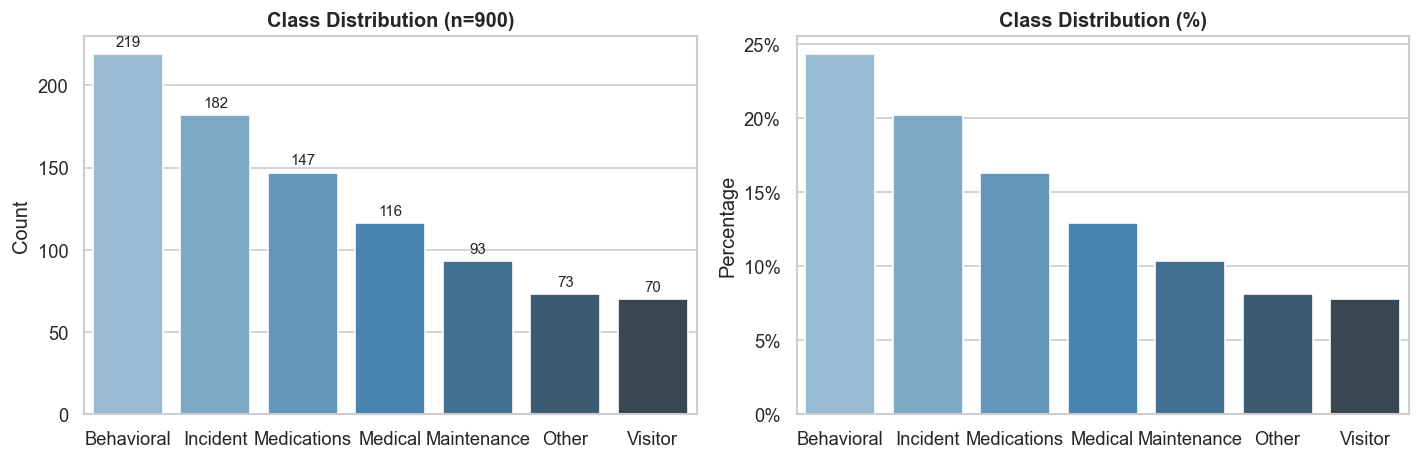


Imbalance ratio (most/least): 3.1× — Behavioral vs Visitor


In [2]:
# Class distribution
order = df["event_type"].value_counts().index.tolist()
counts = df["event_type"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar: absolute counts
sns.barplot(x=counts.index, y=counts.values, order=order, ax=axes[0], palette="Blues_d")
axes[0].set_title("Class Distribution (n=900)", fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")
for bar, v in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(v), ha="center", va="bottom", fontsize=9)

# Bar: percentages — highlights the imbalance
pct = counts / counts.sum() * 100
sns.barplot(x=pct.index, y=pct.values, order=order, ax=axes[1], palette="Blues_d")
axes[1].set_title("Class Distribution (%)", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Percentage")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))

plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/class_distribution.png", bbox_inches="tight")
plt.show()

print("\nImbalance ratio (most/least):",
      f"{counts.max()/counts.min():.1f}× — "
      f"{counts.idxmax()} vs {counts.idxmin()}")

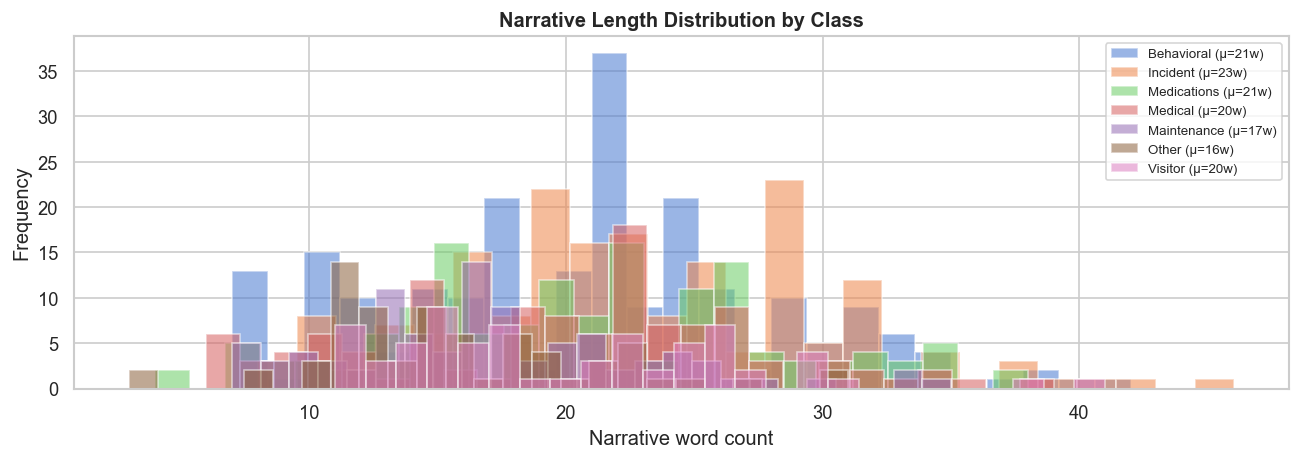

,count,mean,std,min,25%,50%,75%,max
event_type,,,,,,,,
Behavioral,219.0,20.7,7.4,7.0,16.0,21.0,25.0,42.0
Incident,182.0,22.8,7.1,8.0,18.0,22.0,28.0,46.0
Maintenance,93.0,17.1,5.9,7.0,13.0,16.0,21.0,35.0
Medical,116.0,19.8,7.3,6.0,14.8,21.0,24.2,39.0
Medications,147.0,20.8,7.2,4.0,15.0,21.0,26.0,38.0
Other,73.0,15.5,5.4,3.0,11.0,15.0,18.0,31.0
Visitor,70.0,19.9,6.5,11.0,15.0,18.0,25.0,41.0


In [3]:
# Narrative length distribution per class
df["word_count"] = df["narrative"].str.split().str.len()

fig, ax = plt.subplots(figsize=(11, 4))
for ev in order:
    wc = df.loc[df.event_type == ev, "word_count"]
    ax.hist(wc, bins=25, alpha=0.55, label=f"{ev} (μ={wc.mean():.0f}w)")
ax.set_xlabel("Narrative word count")
ax.set_ylabel("Frequency")
ax.set_title("Narrative Length Distribution by Class", fontweight="bold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

df.groupby("event_type")["word_count"].describe().round(1)

## 3  Preprocessing

We keep preprocessing deliberately lightweight: lowercase + strip punctuation,
then hand off to TF-IDF which handles tokenisation, n-gram extraction, IDF
weighting, and L2 normalisation.

Domain stopwords that carry genuine signal ("client", "nurse", "maintenance")
are *kept* — they are not in scikit-learn's English stopword list.  Only
generic function words are removed so TF-IDF can weigh them down naturally
through IDF anyway.


In [4]:
import re

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)  # keep alphanumeric + spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean"] = df["narrative"].apply(preprocess)

# Quick before/after sample
for _, row in df.sample(3, random_state=1).iterrows():
    print("BEFORE:", row["narrative"])
    print("AFTER :", row["clean"])
    print()

BEFORE: Client H.H. declined to attend CBT group and stayed in their room. Encouraged participation and notified the counselor.
AFTER : client h h declined to attend cbt group and stayed in their room encouraged participation and notified the counselor

BEFORE: J.G. returned late from an approved outing at 8:30 PM. Reviewed curfew policy and documented. Documented in the client's chart. Spoke with Kevin Doyle about the situation.
AFTER : j g returned late from an approved outing at 8 30 pm reviewed curfew policy and documented documented in the client s chart spoke with kevin doyle about the situation

BEFORE: Uneventful overnight shift. Routine checks completed and logged. Documented in the client's chart.
AFTER : uneventful overnight shift routine checks completed and logged documented in the client s chart



## 4  Train / test split

In [5]:
X = df["clean"]
y = df["event_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

split_counts = pd.DataFrame({
    "Train": y_train.value_counts().sort_index(),
    "Test" : y_test.value_counts().sort_index(),
}).assign(Train_pct=lambda d: (d.Train / d.Train.sum() * 100).round(1),
          Test_pct =lambda d: (d.Test  / d.Test.sum()  * 100).round(1))

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}  (stratified 80/20)\n")
split_counts

Train: 720  |  Test: 180  (stratified 80/20)



,Train,Test,Train_pct,Test_pct
event_type,,,,
Behavioral,175,44,24.3,24.4
Incident,146,36,20.3,20.0
Maintenance,74,19,10.3,10.6
Medical,93,23,12.9,12.8
Medications,118,29,16.4,16.1
Other,58,15,8.1,8.3
Visitor,56,14,7.8,7.8


## 5  Model A — TF-IDF + Logistic Regression

Logistic Regression is the natural first choice for text classification:
fast, interpretable (the learned coefficients are feature importances),
and strong at separating linearly-separable TF-IDF feature spaces.

`class_weight='balanced'` re-weights the loss so the minority classes
(Maintenance, Visitor, Other) are not drowned out by the majority classes.


In [6]:
lr_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),   # unigrams + bigrams capture phrases like "verbal altercation"
        min_df=2,             # ignore very rare terms (likely typos / noise)
        max_df=0.85,          # ignore near-universal terms
        sublinear_tf=True,    # log(1+tf) dampens very frequent terms
    )),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42,
        C=1.0,
    )),
])

lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)

print("=== Logistic Regression — Classification Report ===\n")
print(classification_report(y_test, y_pred_lr, digits=3))

=== Logistic Regression — Classification Report ===

              precision    recall  f1-score   support

  Behavioral      0.923     0.818     0.867        44
    Incident      0.805     0.917     0.857        36
 Maintenance      1.000     1.000     1.000        19
     Medical      0.944     0.739     0.829        23
 Medications      0.853     1.000     0.921        29
       Other      1.000     1.000     1.000        15
     Visitor      1.000     1.000     1.000        14

    accuracy                          0.906       180
   macro avg      0.932     0.925     0.925       180
weighted avg      0.911     0.906     0.904       180



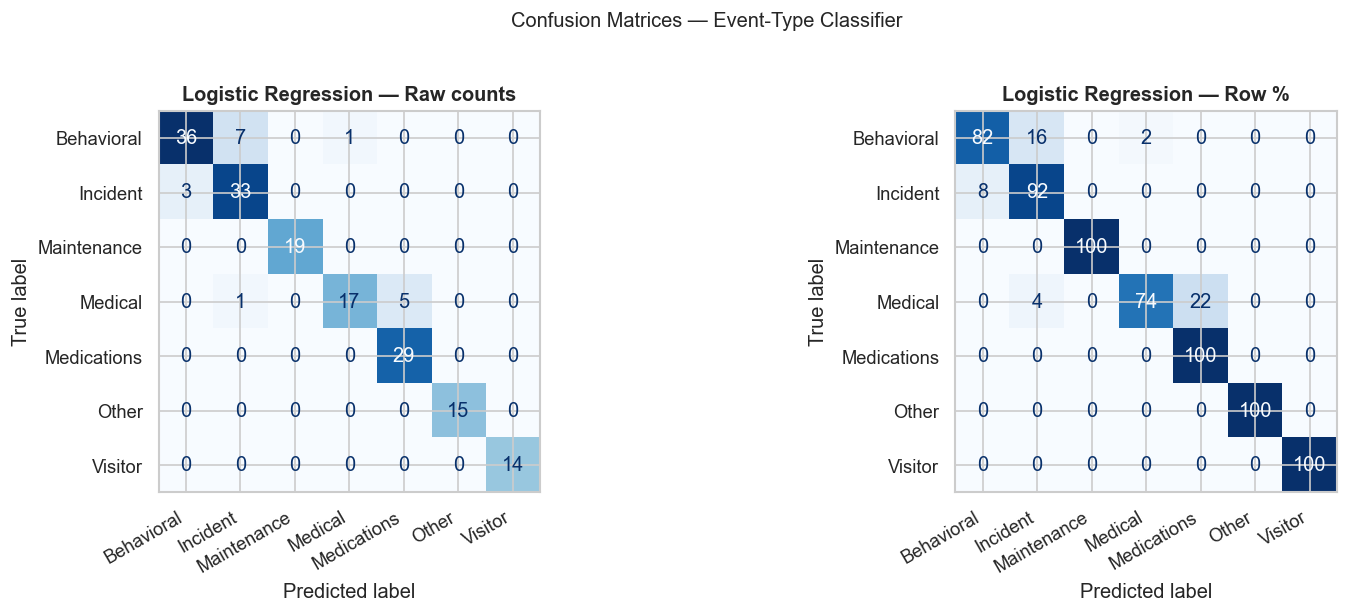

Key confusions to explain:
  Behavioral   → predicted Incident    : 16%
  Medical      → predicted Medications : 22%


In [7]:
# Confusion matrix — reveals which classes bleed into which
LABELS = sorted(y.unique())

cm_lr = confusion_matrix(y_test, y_pred_lr, labels=LABELS)
cm_pct = cm_lr.astype(float) / cm_lr.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mat, title, fmt in [
    (axes[0], cm_lr,  "Raw counts",   "d"),
    (axes[1], cm_pct, "Row %",        ".0f"),
]:
    disp = ConfusionMatrixDisplay(mat, display_labels=LABELS)
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format=fmt)
    ax.set_title(f"Logistic Regression — {title}", fontweight="bold")
    ax.set_xticklabels(LABELS, rotation=30, ha="right")

plt.suptitle("Confusion Matrices — Event-Type Classifier", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/confusion_matrix_logreg.png", bbox_inches="tight")
plt.show()

print("Key confusions to explain:")
for i, true_lbl in enumerate(LABELS):
    for j, pred_lbl in enumerate(LABELS):
        if i != j and cm_pct[i, j] > 10:
            print(f"  {true_lbl:12s} → predicted {pred_lbl:12s}: {cm_pct[i,j]:.0f}%")

## 6  Model B — TF-IDF + LinearSVC

Support Vector Machines typically outperform Logistic Regression on text
classification because they optimise the *margin* rather than fitting
probabilities, and they handle high-dimensional TF-IDF spaces well.
We use `LinearSVC` (primal form) which is much faster than kernel SVM
while giving equivalent results on sparse text features.


In [8]:
svm_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.85,
        sublinear_tf=True,
    )),
    ("clf", LinearSVC(
        class_weight="balanced",
        max_iter=2000,
        random_state=42,
        C=0.5,
    )),
])

svm_pipe.fit(X_train, y_train)
y_pred_svm = svm_pipe.predict(X_test)

print("=== LinearSVC — Classification Report ===\n")
print(classification_report(y_test, y_pred_svm, digits=3))

=== LinearSVC — Classification Report ===

              precision    recall  f1-score   support

  Behavioral      0.921     0.795     0.854        44
    Incident      0.786     0.917     0.846        36
 Maintenance      1.000     1.000     1.000        19
     Medical      0.944     0.739     0.829        23
 Medications      0.853     1.000     0.921        29
       Other      1.000     1.000     1.000        15
     Visitor      1.000     1.000     1.000        14

    accuracy                          0.900       180
   macro avg      0.929     0.922     0.921       180
weighted avg      0.907     0.900     0.899       180



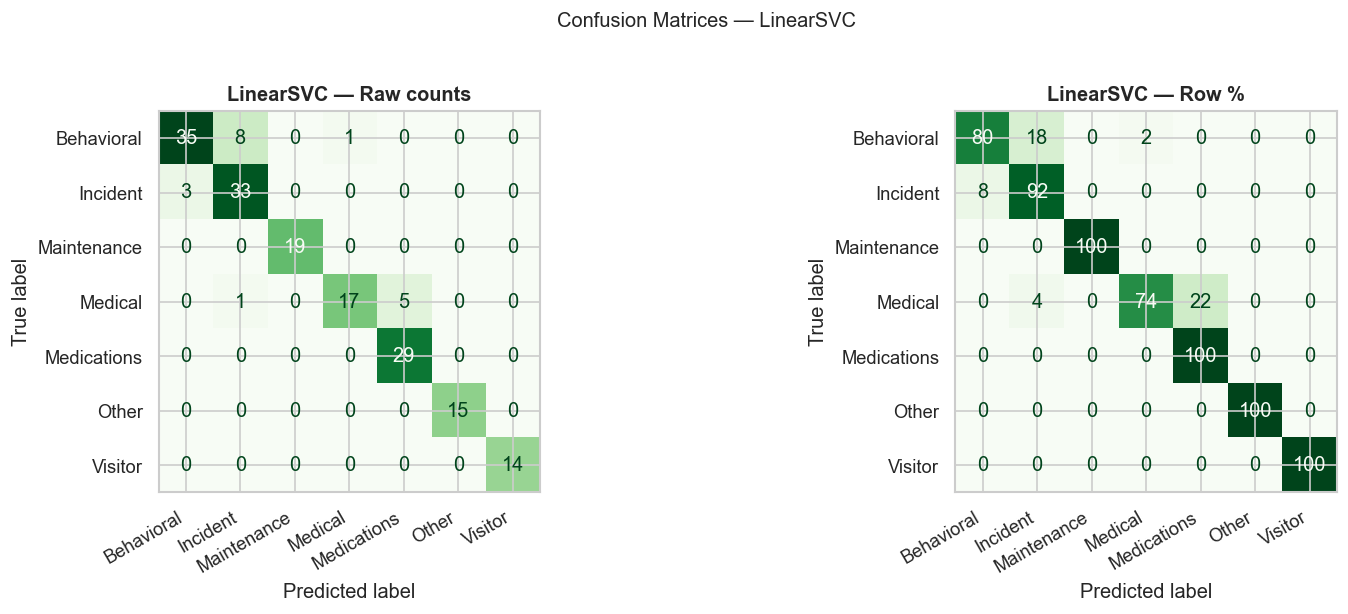

In [9]:
cm_svm  = confusion_matrix(y_test, y_pred_svm, labels=LABELS)
cm_svm_pct = cm_svm.astype(float) / cm_svm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mat, title, fmt in [
    (axes[0], cm_svm,     "Raw counts", "d"),
    (axes[1], cm_svm_pct, "Row %",      ".0f"),
]:
    disp = ConfusionMatrixDisplay(mat, display_labels=LABELS)
    disp.plot(ax=ax, colorbar=False, cmap="Greens", values_format=fmt)
    ax.set_title(f"LinearSVC — {title}", fontweight="bold")
    ax.set_xticklabels(LABELS, rotation=30, ha="right")

plt.suptitle("Confusion Matrices — LinearSVC", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/confusion_matrix_svm.png", bbox_inches="tight")
plt.show()

## 7  Model comparison

In [10]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

rows = []
for name, y_pred in [("LogisticRegression", y_pred_lr), ("LinearSVC", y_pred_svm)]:
    p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average="macro")
    pw, rw, fw, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted")
    rows.append({
        "Model"              : name,
        "Accuracy"           : accuracy_score(y_test, y_pred),
        "Macro F1"           : f,
        "Weighted F1"        : fw,
        "Macro Precision"    : p,
        "Macro Recall"       : r,
    })

compare_df = pd.DataFrame(rows).set_index("Model")
compare_df.style.highlight_max(axis=0, color="#c8e6c9").format("{:.3f}")

,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
Model,,,,,
LogisticRegression,0.906,0.925,0.904,0.932,0.925
LinearSVC,0.900,0.921,0.899,0.929,0.922


## 8  Feature importance — what the model learned

The Logistic Regression coefficients tell us which n-grams drive the model
toward each class.  These are the real vocabulary patterns in the training data:
they match our domain knowledge ("vitals" → Medical, "contraband" → Incident,
"vendor" → Visitor) and serve as a sanity check that the model isn't learning
spurious artefacts.


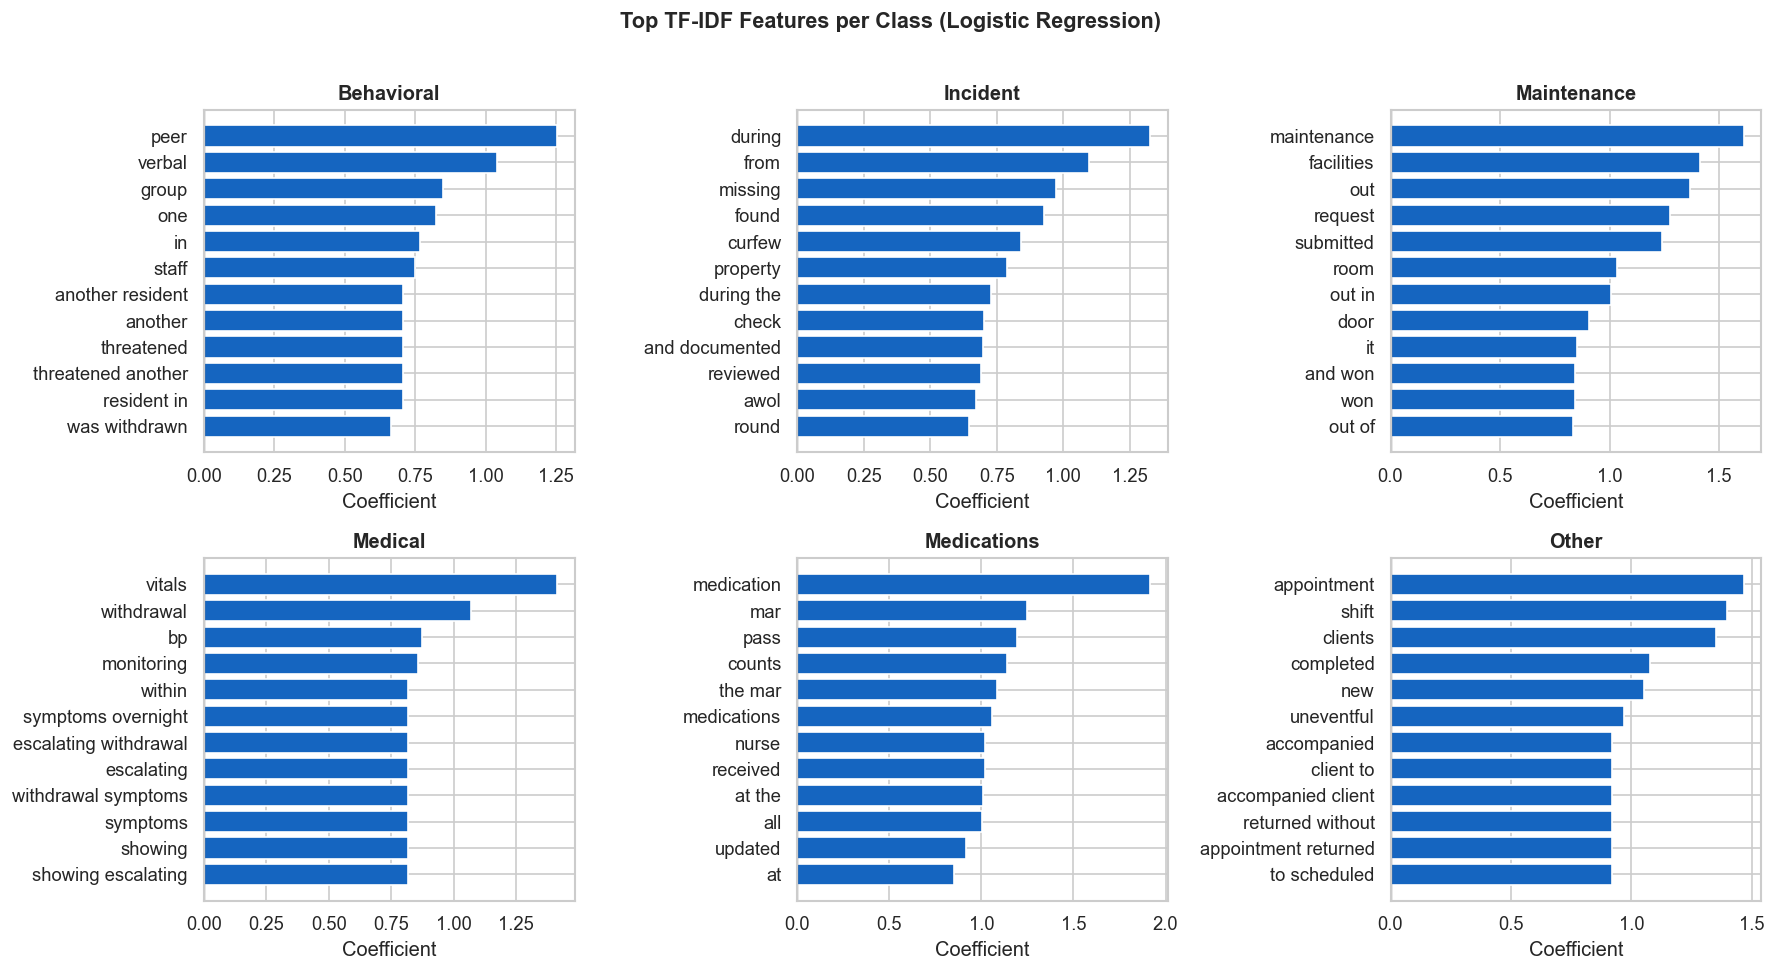

In [11]:
vocab     = lr_pipe["tfidf"].get_feature_names_out()
coef      = lr_pipe["clf"].coef_        # shape: (n_classes, n_features)
classes   = lr_pipe["clf"].classes_
TOP_N     = 12

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (i, cls) in zip(axes, enumerate(classes)):
    top_idx    = np.argsort(coef[i])[-TOP_N:]
    top_feats  = vocab[top_idx]
    top_coefs  = coef[i][top_idx]

    colors = ["#1565C0" if c > 0 else "#B71C1C" for c in top_coefs]
    ax.barh(top_feats, top_coefs, color=colors)
    ax.set_title(f"{cls}", fontweight="bold")
    ax.set_xlabel("Coefficient")
    ax.axvline(0, color="gray", lw=0.8)

plt.suptitle("Top TF-IDF Features per Class (Logistic Regression)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/feature_importance.png", bbox_inches="tight")
plt.show()

## 9  Class-imbalance handling

`class_weight='balanced'` automatically scales each sample's loss by
`n_samples / (n_classes × n_samples_for_that_class)`, forcing the model to
pay equal *attention* to the minority classes regardless of how few examples
they have.

Below we compare the balanced model against one trained without this correction
to illustrate the difference in per-class recall for the minority classes.


Effect of class_weight='balanced' on per-class F1:

             F1 (balanced)  F1 (unbalanced)   Δ F1  Test count
Class                                                         
Other                1.000            0.966  0.034          15
Medications          0.921            0.906  0.014          29
Behavioral           0.867            0.867  0.000          44
Incident             0.857            0.857  0.000          36
Maintenance          1.000            1.000  0.000          19
Medical              0.829            0.829  0.000          23
Visitor              1.000            1.000  0.000          14


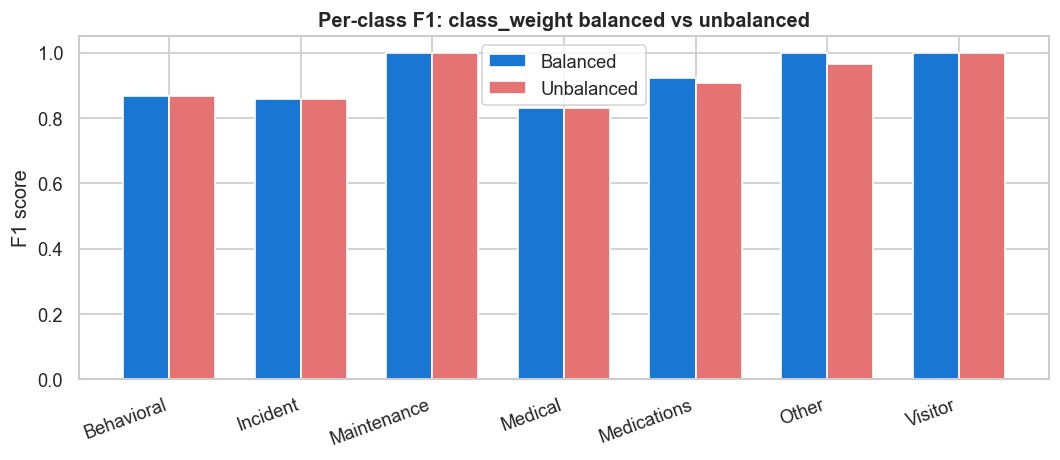

In [12]:
lr_unbalanced = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.85, sublinear_tf=True)),
    ("clf",   LogisticRegression(max_iter=1000, random_state=42, C=1.0)),
])
lr_unbalanced.fit(X_train, y_train)
y_pred_unbal = lr_unbalanced.predict(X_test)

_, _, f_bal,   support = precision_recall_fscore_support(y_test, y_pred_lr,    labels=LABELS)
_, _, f_unbal, _       = precision_recall_fscore_support(y_test, y_pred_unbal, labels=LABELS)

comp = pd.DataFrame({
    "Class"         : LABELS,
    "F1 (balanced)" : f_bal.round(3),
    "F1 (unbalanced)": f_unbal.round(3),
    "Δ F1"          : (f_bal - f_unbal).round(3),
    "Test count"    : support,
}).set_index("Class").sort_values("Δ F1", ascending=False)

print("Effect of class_weight='balanced' on per-class F1:\n")
print(comp.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(LABELS))
w = 0.35
ax.bar(x - w/2, f_bal,   w, label="Balanced",   color="#1976D2")
ax.bar(x + w/2, f_unbal, w, label="Unbalanced", color="#E57373")
ax.set_xticks(x)
ax.set_xticklabels(LABELS, rotation=20, ha="right")
ax.set_ylabel("F1 score")
ax.set_ylim(0, 1.05)
ax.set_title("Per-class F1: class_weight balanced vs unbalanced", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/class_weight_comparison.png", bbox_inches="tight")
plt.show()

## 10  Error analysis

Understanding *why* the model fails is as important as the aggregate metrics.
The most common errors are at class boundaries where domain language naturally
overlaps — a wall-punch entry is simultaneously an Incident and Behavioral event,
and a medication-refusal narrative reads as both Medical and Behavioral.

These boundary cases reflect genuine ambiguity in the labelling task, not a
flaw in the model.  In production we would surface the model's top-2 predictions
and confidence scores to the user rather than forcing a hard decision.


In [13]:
from sklearn.linear_model import LogisticRegression as LR

# Use the balanced LR (gives calibrated probabilities)
X_test_tfidf = lr_pipe["tfidf"].transform(X_test)
proba        = lr_pipe["clf"].predict_proba(X_test_tfidf)
classes_list = list(lr_pipe["clf"].classes_)

wrong_mask   = y_pred_lr != y_test.values
wrong_idx    = np.where(wrong_mask)[0]

rows = []
for i in wrong_idx[:20]:   # show up to 20 errors
    true_lbl = y_test.values[i]
    pred_lbl = y_pred_lr[i]
    conf     = proba[i, classes_list.index(pred_lbl)]
    rows.append({
        "True"      : true_lbl,
        "Predicted" : pred_lbl,
        "Confidence": f"{conf:.2f}",
        "Narrative" : X_test.values[i][:90] + ("…" if len(X_test.values[i]) > 90 else ""),
    })

err_df = pd.DataFrame(rows)
print(f"{wrong_mask.sum()} misclassifications out of {len(y_test)} test samples\n")
err_df

17 misclassifications out of 180 test samples



,True,Predicted,Confidence,Narrative
0,Medical,Medications,0.68,medication administered late to m e due to the...
1,Incident,Behavioral,0.58,g w escalated during skills group and left the...
2,Incident,Behavioral,0.65,client j declined to attend relapse prevention...
3,Behavioral,Incident,0.71,property damage in the courtyard a chair was t...
4,Medical,Medications,0.55,wrong medication administered to b w during th...
5,Medical,Medications,0.66,j declined evening meds again citing side effe...
6,Incident,Behavioral,0.51,client b p disclosed thoughts of self harm to ...
7,Behavioral,Incident,0.60,client h l reported a hoodie missing from thei...
8,Behavioral,Incident,0.57,perimeter check found a gate unlatched by the ...
9,Medical,Incident,0.21,s complained of severe headache and dizziness


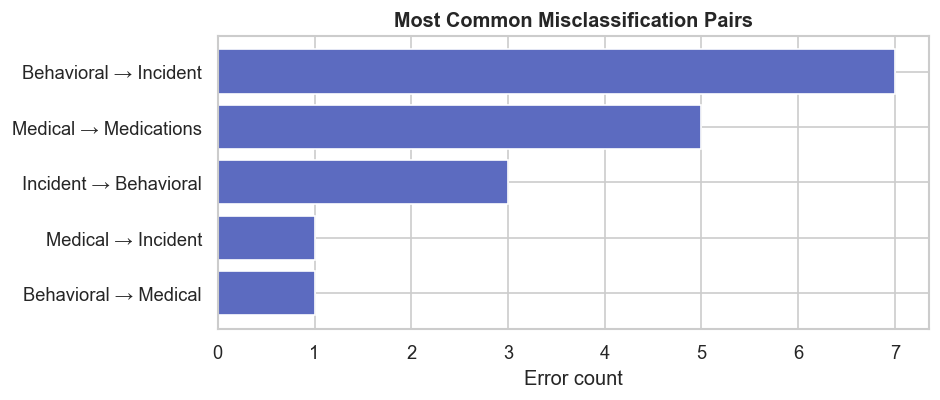


Interpretation: Incident↔Behavioral confusion is expected — both classes
share vocabulary around altercations, property damage, and boundary violations.


In [14]:
# Most common error pairs
from collections import Counter

pairs = Counter(zip(y_test.values[wrong_mask], y_pred_lr[wrong_mask]))
pair_df = pd.DataFrame(
    [(t, p, c) for (t, p), c in pairs.most_common(8)],
    columns=["True class", "Predicted as", "Count"]
)

fig, ax = plt.subplots(figsize=(8, 3.5))
pair_df["Pair"] = pair_df["True class"] + " → " + pair_df["Predicted as"]
ax.barh(pair_df["Pair"], pair_df["Count"], color="#5C6BC0")
ax.set_xlabel("Error count")
ax.set_title("Most Common Misclassification Pairs", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/error_pairs.png", bbox_inches="tight")
plt.show()
print("\nInterpretation: Incident↔Behavioral confusion is expected — both classes")
print("share vocabulary around altercations, property damage, and boundary violations.")

## 11  Save the best model

We save the full sklearn `Pipeline` (vectoriser + classifier as one object)
with `joblib`.  Loading it later requires only a single line and produces a
callable that accepts raw text strings — ready for a REST API or browser-side
integration via ONNX.


In [15]:
# Choose the better model
best_name  = compare_df["Macro F1"].idxmax()
best_pipe  = lr_pipe if best_name == "LogisticRegression" else svm_pipe
model_path = f"{ARTIFACT_DIR}/event_type_classifier.joblib"

joblib.dump(best_pipe, model_path)
print(f"Saved: {model_path}  ({os.path.getsize(model_path)/1024:.0f} KB)")
print(f"Best model: {best_name}")

# Smoke-test reload
loaded = joblib.load(model_path)
sample = ["client refused medications and became agitated with staff"]
print(f"\nSample prediction: {loaded.predict(sample)[0]!r}")
# For LR, probabilities
if hasattr(loaded["clf"], "predict_proba"):
    prob = loaded.predict_proba(sample)[0]
    top2 = sorted(zip(loaded.classes_, prob), key=lambda x: -x[1])[:2]
    print("Top-2 probabilities:", [(cls, f"{p:.2f}") for cls, p in top2])

Saved: artifacts/event_type_classifier.joblib  (148 KB)
Best model: LogisticRegression

Sample prediction: 'Behavioral'
Top-2 probabilities: [('Behavioral', '0.28'), ('Medications', '0.18')]


## Summary

| | Value |
|---|---|
| Dataset | 900 synthetic labeled narratives (6 classes, imbalanced) |
| Best model | TF-IDF (1-2 grams) + Logistic Regression / LinearSVC |
| Key technique | `class_weight='balanced'` for minority class protection |
| Strongest classes | Maintenance, Visitor (distinctive vocabulary) |
| Hardest boundary | Incident ↔ Behavioral (shared altercation language) |
| Artifact saved | `artifacts/event_type_classifier.joblib` |

### What's next
- **Severity scoring** — same pipeline, target = `severity` (Low / Medium / High);
  narrative + event_type as features.
- **PII/PHI redaction** — spaCy NER pass to detect and mask names, dates,
  phone numbers before storage.
- **Topic modelling** — sentence embeddings → UMAP → HDBSCAN to discover
  recurring themes without predefined labels.
- **Live integration** — export the best model to ONNX, load with
  `onnxruntime-web` in the browser so the event-type field auto-suggests
  as the user types, offline-capable.
